In [9]:
import torch
import os

dir_loaders = 'dataloaders'
rock_loader = torch.load(os.path.join(dir_loaders, 'rock_dataloader_zeros.pt'), weights_only=False)
paper_loader = torch.load(os.path.join(dir_loaders, 'paper_dataloader_zeros.pt'), weights_only=False)
scissor_loader = torch.load(os.path.join(dir_loaders, 'scissor_dataloader_zeros.pt'), weights_only=False)

all_rocks = []
for x, y in rock_loader:
    all_rocks.append(x[y==1])
all_rocks = torch.cat(all_rocks, dim=0)

all_papers = []
for x, y in paper_loader:
    all_papers.append(x[y==1])
all_papers = torch.cat(all_papers, dim=0)

all_scissors = []
for x, y in scissor_loader:
    all_scissors.append(x[y==1])
all_scissors = torch.cat(all_scissors, dim=0)

print(all_rocks.shape)
print(all_papers.shape)
print(all_scissors.shape)

torch.Size([296, 1, 8, 400])
torch.Size([296, 1, 8, 400])
torch.Size([296, 1, 8, 400])


In [ ]:
import torch
import numpy as np
import pywt
from scipy.signal import welch
import os

# ---------- Feature functions ----------
def rms(signal):
    return np.sqrt(np.mean(signal**2))

def waveform_length(signal):
    return np.sum(np.abs(np.diff(signal)))

def zero_crossings(signal, threshold=0.01):
    # Count sign changes with threshold
    return np.sum(((signal[:-1] * signal[1:]) < 0) &
                  (np.abs(signal[:-1] - signal[1:]) > threshold))

def slope_sign_changes(signal, threshold=0.01):
    # Detect slope sign changes
    diff = np.diff(signal)
    return np.sum(((diff[:-1] * diff[1:]) < 0) &
                  (np.abs(diff[:-1] - diff[1:]) > threshold))

def median_freq(signal, fs=1000):  # <-- adjust fs if known
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    cumulative = np.cumsum(psd)
    cutoff = cumulative[-1] / 2
    return freqs[np.where(cumulative >= cutoff)[0][0]]

def sample_entropy(signal, m=2, r=0.2):
    # Approximate sample entropy
    N = len(signal)
    r *= np.std(signal)
    
    def _phi(m):
        x = np.array([signal[i:i+m] for i in range(N - m + 1)])
        C = np.sum(np.sum(np.abs(x[:,None] - x[None,:]), axis=2) <= r, axis=0) - 1
        return np.sum(C) / ((N - m + 1) * (N - m))
    
    return -np.log(_phi(m+1) / _phi(m) + 1e-10)

def shannon_entropy(signal, bins=30):
    hist, _ = np.histogram(signal, bins=bins, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))

def wavelet_energy(signal, wavelet='db4', level=3):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = [np.sum(np.square(c)) for c in coeffs]
    return np.sum(energies)

def higuchi_fd(signal, kmax=10):
    # Higuchi fractal dimension
    N = len(signal)
    L = []
    x = signal
    for k in range(1, kmax+1):
        Lk = []
        for m in range(k):
            idx = np.arange(m, N, k)
            Lm = np.sum(np.abs(np.diff(x[idx]))) * (N-1)/(((N-m)//k) * k)
            Lk.append(Lm)
        L.append(np.mean(Lk))
    L = np.log(L)
    ln_k = np.log(1.0/np.arange(1, kmax+1))
    return -np.polyfit(ln_k, L, 1)[0]

# ---------- Main extractor ----------
def extract_emg_features(emg_tensor, fs=1000):
    """
    emg_tensor: torch.Size([samples, 1, channels, timesteps])
    Returns: numpy array of shape [samples, channels * n_features]
    """
    emg_np = emg_tensor.squeeze(1).numpy()  # shape: [samples, channels, timesteps]
    n_samples, n_channels, n_timesteps = emg_np.shape
    
    features = []
    for s in range(n_samples):
        sample_feats = []
        for ch in range(n_channels):
            sig = emg_np[s, ch, :]
            
            feats = [
                rms(sig),
                waveform_length(sig),
                zero_crossings(sig),
                slope_sign_changes(sig),
                median_freq(sig, fs),
                sample_entropy(sig),
                shannon_entropy(sig),
                wavelet_energy(sig),
                higuchi_fd(sig),
            ]
            sample_feats.extend(feats)
        features.append(sample_feats)
    
    return np.array(features)

# ---------- Example usage ----------
if __name__ == "__main__":
    dir_loaders = 'dataloaders'
    types = ['rock', 'paper', 'scissor']

    feature_data = {}

    for _type in types:
        print(f'Processing {_type} data...')
        loader = torch.load(os.path.join(dir_loaders, f'{_type}_dataloader_zeros.pt'), weights_only=False)

        # Load data
        all_x = []
        for x, y in loader:
            all_x.append(x[y==1])
        all_x = torch.cat(all_x, dim=0)

        X_feats = extract_emg_features(all_x, fs=100)
        print("Feature matrix shape:", X_feats.shape)

        feature_data[_type] = X_feats



Processing rock data...
Feature matrix shape: (296, 72)
Processing paper data...
Feature matrix shape: (296, 72)
Processing scissor data...
Feature matrix shape: (296, 72)


{'rock': array([[ 1.71956646e+00,  6.83316895e+02,  1.86000000e+02, ...,
          5.50473609e+00,  7.85940063e+02, -1.01550887e+00],
        [ 2.44737387e+00,  9.80854797e+02,  1.83000000e+02, ...,
          7.04785799e+00,  1.24743726e+03, -1.02756511e+00],
        [ 1.71318662e+00,  7.12751648e+02,  1.63000000e+02, ...,
          7.14203713e+00,  5.83215210e+02, -1.04814357e+00],
        ...,
        [ 1.71892118e+00,  6.60897705e+02,  1.63000000e+02, ...,
          4.69982238e+00,  3.94543396e+02, -1.04110007e+00],
        [ 1.78124213e+00,  6.05914185e+02,  1.79000000e+02, ...,
          3.94739238e+00,  2.52473633e+02, -9.91947189e-01],
        [ 1.53050864e+00,  4.18454315e+02,  1.66000000e+02, ...,
          3.56182861e+00,  1.41616226e+02, -1.02005816e+00]],
       shape=(296, 72)),
 'paper': array([[ 6.56799495e-01,  2.56718750e+02,  1.64000000e+02, ...,
          2.19760726e+00,  1.28444824e+02, -1.00029790e+00],
        [ 5.19165158e-01,  1.67192963e+02,  1.45000000e+02, ..

Paper vs Scissor: 0.945380990871888
Rock vs Scissor: 12.936071846466302
Rock vs Paper: 10.888213461060227


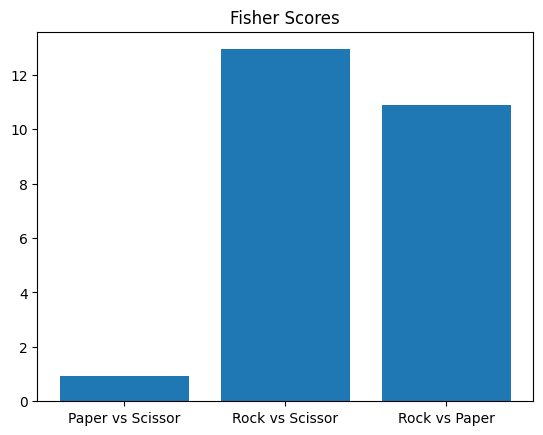

In [15]:
def compute_fisher_scores(data1, data2):
    m1 = np.mean(data1, axis=0)
    m2 = np.mean(data2, axis=0)
    v1 = np.var(data1, axis=0, ddof=0)
    v2 = np.var(data2, axis=0, ddof=0)
    scores = (m1 - m2)**2 / (v1 + v2 + 1e-12)
    return np.max(scores)

paper_scissor = compute_fisher_scores(feature_data["paper"], feature_data["scissor"])
rock_scissor = compute_fisher_scores(feature_data["rock"], feature_data["scissor"])
rock_paper = compute_fisher_scores(feature_data["rock"], feature_data["paper"])

print(f"Paper vs Scissor: {paper_scissor}")
print(f"Rock vs Scissor: {rock_scissor}")
print(f"Rock vs Paper: {rock_paper}")

import matplotlib.pyplot as plt

plt.bar(x=["Paper vs Scissor", "Rock vs Scissor", "Rock vs Paper"], height=[paper_scissor, rock_scissor, rock_paper])
plt.title("Fisher Scores")
plt.show()